# Module 1 — Basic Physical and Chemical Structure of the Troposphere and Stratosphere
### B4 Chemistry in the Atmosphere · companion notebook

Covers Exercise 1 (number density), the hydrostatic/scale-height relation, and Exercise 2
(column amount), from `lectures/01-basic-structure-troposphere-stratosphere.md`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (7, 4.5)
plt.rcParams['font.size'] = 11

kB = 1.38e-23   # J/K
R = 8.314       # J/mol/K
NA = 6.022e23   # /mol
g = 9.81        # m/s^2

## Exercise 1 — number density at different altitudes

$$\frac{\#}{V} = \frac{p}{k_B T}$$

In [2]:
def number_density(p_pa, T_K):
    """Number density in molecules/cm^3, given pressure in Pa and temperature in K."""
    n_per_m3 = p_pa / (kB * T_K)
    return n_per_m3 / 1e6   # convert m^-3 -> cm^-3

# Check against the notes: 298 K, 1 bar (100,000 Pa)
n0 = number_density(1e5, 298)
print(f"[M] at 298 K, 1 bar = {n0:.3e} molecules/cm^3")
print("(notes value: 2.43e19 molecules/cm^3)")

[M] at 298 K, 1 bar = 2.432e+19 molecules/cm^3
(notes value: 2.43e19 molecules/cm^3)


## Scale height and the barometric law

$$H = \frac{RT}{Mg}, \qquad p = p_0 e^{-z/H}, \qquad [M] = [M]_0 e^{-z/H}$$

In [3]:
M_air = 28.9e-3   # kg/mol
T_avg = 250        # K, a representative average atmospheric temperature

H = R * T_avg / (M_air * g)
print(f"Scale height H = {H/1000:.2f} km (notes: 6-7.5 km)")

Scale height H = 7.33 km (notes: 6-7.5 km)


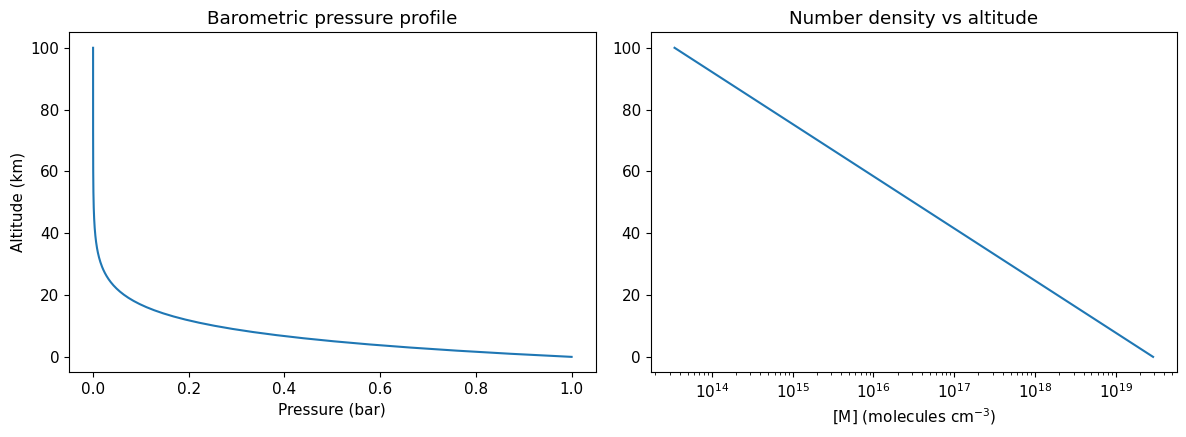

Ratio [M](16km)/[M](0km) = 0.112 (expect ~0.1)


In [4]:
z_km = np.linspace(0, 100, 200)
z_m = z_km * 1000

p0 = 1e5           # Pa, surface pressure
p = p0 * np.exp(-z_m / H)
M_conc = number_density(p, T_avg)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(p/1e5, z_km)
axes[0].set_xlabel('Pressure (bar)')
axes[0].set_ylabel('Altitude (km)')
axes[0].set_title('Barometric pressure profile')

axes[1].semilogx(M_conc, z_km)
axes[1].set_xlabel('[M] (molecules cm$^{-3}$)')
axes[1].set_title('Number density vs altitude')
plt.tight_layout()
plt.show()

# Sanity check: factor of ~10 drop per ~16 km, as the notes state
ratio = M_conc[np.argmin(np.abs(z_km-16))] / M_conc[0]
print(f"Ratio [M](16km)/[M](0km) = {ratio:.3f} (expect ~0.1)")

## Comparing against the real atmosphere: the 1976 US Standard Atmosphere

Our barometric-law calculation above assumed a single constant temperature (`T_avg = 250 K`)
for the whole atmosphere -- a reasonable first approximation, but the real atmosphere's
temperature varies with altitude (Fig 1.1/1.2 in the notes: it falls through the troposphere,
is roughly constant through the tropopause, then *rises* through the stratosphere). We load a
real reference profile -- the 1976 US Standard Atmosphere -- to see how much this matters.

In [5]:
import pandas as pd

atm = pd.read_csv('../data/us_standard_atmosphere_1976.csv')
atm.head()

,altitude_km,temperature_K,pressure_Pa,density_kg_m3,number_density_cm3
0,0.0,288.15,101325.00000,1.224999,2.546916e+19
1,0.5,284.90,95460.83934,1.167268,2.426887e+19
2,1.0,281.65,89874.57050,1.111642,2.311233e+19
3,1.5,278.40,84556.00484,1.058067,2.199844e+19
4,2.0,275.15,79495.21551,1.006490,2.092609e+19


## Recreating Figure 1.1 — the atmospheric temperature profile

The notes' Fig 1.1 shows how atmospheric temperature varies with altitude, divided into
named layers (troposphere, stratosphere, mesosphere, ...) separated by "pauses" -- turning
points in the temperature gradient. We recreate it directly from the real 1976 US Standard
Atmosphere data, with the layer boundaries found automatically from the data itself (a local
temperature-gradient sign change), rather than hard-coded.

In [6]:
z = atm['altitude_km'].values
T = atm['temperature_K'].values

# Find the "pauses": genuine turning points in T(z). A naive sign-change-in-gradient
# detector gets confused by the isothermal (zero-gradient) layers in between -- instead,
# classify the gradient's sign into +1/0/-1 and find where consecutive *non-zero* signs
# actually flip (ignoring flat/isothermal stretches in between).
dT = np.gradient(T, z)
sign = np.sign(np.round(dT, 3))

nonzero_signs = sign[sign != 0]
nonzero_idx = np.where(sign != 0)[0]
flip_points = np.where(np.diff(nonzero_signs) != 0)[0]
pause_altitudes = list(z[nonzero_idx[flip_points]])

# Our table stops at 86 km, right at the real mesopause (~85 km) -- but temperature is
# still falling at that point in our data, so no genuine sign-flip is detectable within
# the range we have. We know from the model's own definition that this is (approximately)
# the mesopause, so label the top of the dataset accordingly rather than silently omitting it.
if len(pause_altitudes) < 3:
    pause_altitudes.append(z.max())

print('Detected/assigned pause altitudes (km):', np.round(pause_altitudes, 1))
print('(Expected close to: tropopause ~11, stratopause ~47-51, mesopause ~85; the last')
print(' value is the edge of our dataset, standing in for the mesopause -- see note above)')

Detected/assigned pause altitudes (km): [11. 47. 86.]
(Expected close to: tropopause ~11, stratopause ~47-51, mesopause ~85; the last
 value is the edge of our dataset, standing in for the mesopause -- see note above)


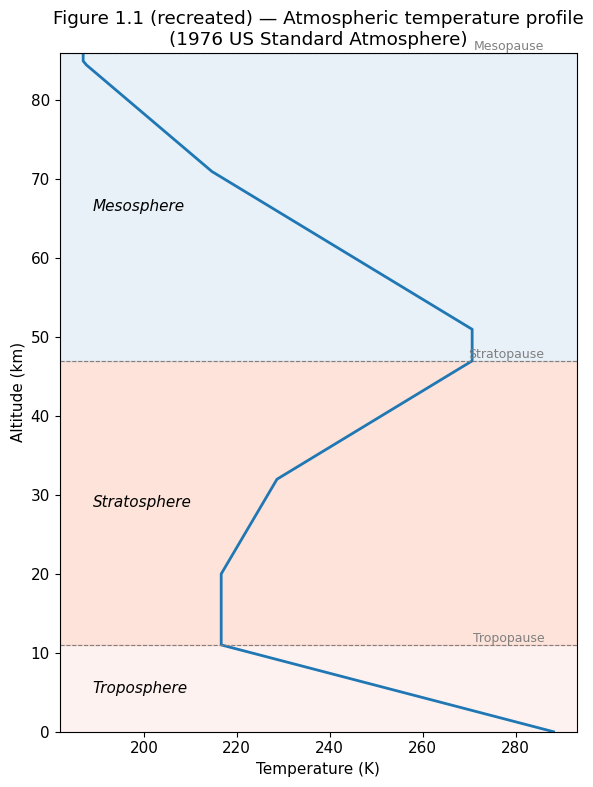

Saved to assets/figures/m1-fig1-1-temp-profile-from-data.png


In [7]:
fig, ax = plt.subplots(figsize=(6, 8))
ax.plot(T, z, color='C0', lw=2)

# Shade and label the named layers using the detected pause altitudes
layer_bounds = [0] + list(pause_altitudes) + [z.max()]
layer_names = ['Troposphere', 'Stratosphere', 'Mesosphere']
colors = ['#fde0dd', '#fcbba1', '#c6dbef']
for i, name in enumerate(layer_names):
    ax.axhspan(layer_bounds[i], layer_bounds[i+1], color=colors[i], alpha=0.4, zorder=0)
    y_mid = (layer_bounds[i] + layer_bounds[i+1]) / 2
    ax.text(T.min()+2, y_mid, name, va='center', fontsize=11, style='italic')

pause_labels = ['Tropopause', 'Stratopause', 'Mesopause']
for alt, label in zip(pause_altitudes, pause_labels):
    ax.axhline(alt, color='gray', ls='--', lw=0.8)
    ax.text(T.max()-2, alt, label, va='bottom', ha='right', fontsize=9, color='gray')

ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Altitude (km)')
ax.set_title('Figure 1.1 (recreated) \u2014 Atmospheric temperature profile\n(1976 US Standard Atmosphere)')
ax.set_ylim(0, z.max())
plt.tight_layout()

# Save into assets/figures so the markdown lecture file can reference it directly
plt.savefig('../assets/figures/m1-fig1-1-temp-profile-from-data.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved to assets/figures/m1-fig1-1-temp-profile-from-data.png")

This recreates the shape and layer structure of the notes' Fig 1.1 directly from real
reference data, rather than as a static scanned image. Because it's generated here, it's easy
to adapt -- e.g. re-run with a different colour scheme, add a second profile for comparison
(a different latitude/season, if you had that data), or extend to a full-thermosphere dataset
if you find one that goes beyond 86 km.

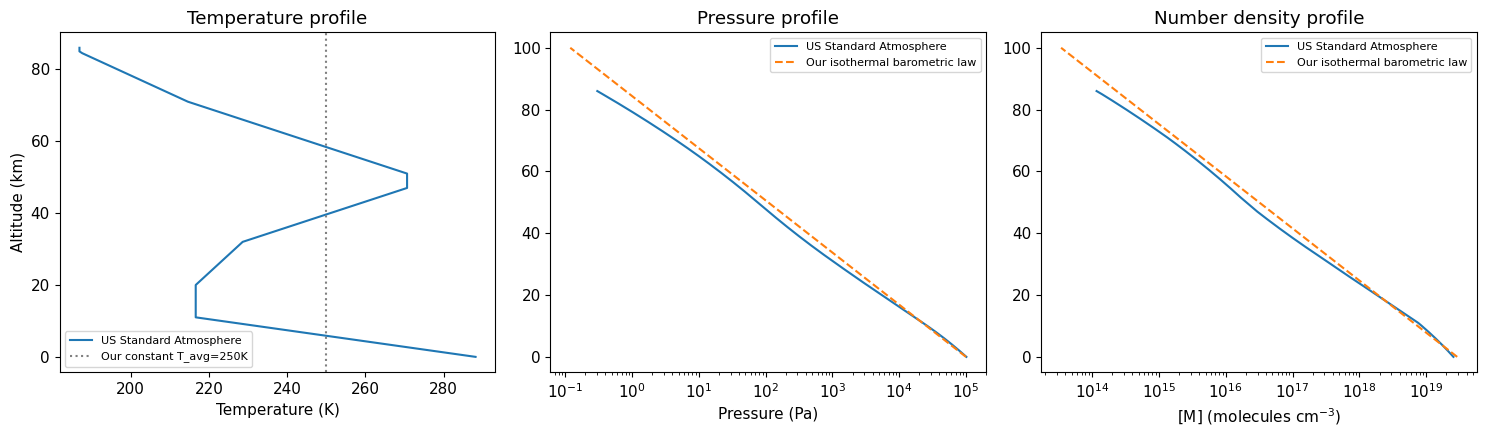

Local scale height near the surface: 8.05 km
Local scale height near 50 km:        7.92 km
Our constant-T approximation used:    H = 7.33 km


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(atm['temperature_K'], atm['altitude_km'], label='US Standard Atmosphere')
axes[0].axvline(T_avg, color='gray', ls=':', label=f'Our constant T_avg={T_avg}K')
axes[0].set_xlabel('Temperature (K)'); axes[0].set_ylabel('Altitude (km)')
axes[0].legend(fontsize=8); axes[0].set_title('Temperature profile')

axes[1].semilogx(atm['pressure_Pa'], atm['altitude_km'], label='US Standard Atmosphere')
axes[1].semilogx(p, z_km, '--', label='Our isothermal barometric law')
axes[1].set_xlabel('Pressure (Pa)')
axes[1].legend(fontsize=8); axes[1].set_title('Pressure profile')

axes[2].semilogx(atm['number_density_cm3'], atm['altitude_km'], label='US Standard Atmosphere')
axes[2].semilogx(M_conc, z_km, '--', label='Our isothermal barometric law')
axes[2].set_xlabel('[M] (molecules cm$^{-3}$)')
axes[2].legend(fontsize=8); axes[2].set_title('Number density profile')

plt.tight_layout()
plt.show()

# How much does the isothermal approximation's scale height differ from reality?
# Fit an effective local scale height to the real profile near the surface and near 50 km.
import numpy as np
def local_scale_height(alt_col, p_col, z_target, window=2):
    mask = (alt_col > z_target-window) & (alt_col < z_target+window)
    logp = np.log(p_col[mask])
    z = alt_col[mask]
    slope = np.polyfit(z, logp, 1)[0]   # d(ln p)/dz, units 1/km
    return -1/slope

H_surface = local_scale_height(atm['altitude_km'].values, atm['pressure_Pa'].values, 2)
H_50km = local_scale_height(atm['altitude_km'].values, atm['pressure_Pa'].values, 50)
print(f"Local scale height near the surface: {H_surface:.2f} km")
print(f"Local scale height near 50 km:        {H_50km:.2f} km")
print(f"Our constant-T approximation used:    H = {H/1000:.2f} km")


The real scale height varies by roughly a factor of ~1.3 between the cold tropopause
region and the warm stratopause -- consistent with $H=RT/Mg$ depending directly on T. Our
single constant-T approximation from Exercise 1/the barometric law captures the right *order
of magnitude* everywhere, but noticeably underestimates pressure at high altitude, where the
real atmosphere is warmer (and hence has a taller scale height) than our fixed `T_avg` assumed.

## Exercise 2 — column amount of a well-mixed gas

$$\text{Column} = [x]_0 \cdot H$$

We reproduce the ozone column example: a well-mixed gas at some surface mixing ratio, using the
scale height, should come out close to the ~300 DU quoted in the notes for ozone (ozone isn't
actually well-mixed — it peaks in the stratosphere — but this illustrates the mechanics of the
column integral for the well-mixed case in Exercise 2, e.g. for a long-lived tracer).

In [9]:
DU = 2.69e16   # molecules/cm^2 per Dobson Unit

def column_well_mixed(mixing_ratio, surface_T=288, surface_p=1e5, H_km=None):
    M0 = number_density(surface_p, surface_T)   # molecules/cm^3 at the surface
    x0 = mixing_ratio * M0
    H_use = (H_km * 1000) if H_km else H
    column_cm2 = x0 * (H_use * 100)   # H in cm
    return column_cm2

# Example: a hypothetical well-mixed gas at 80 ppb (O3-like surface mixing ratio)
col = column_well_mixed(80e-9)
print(f"Column = {col:.3e} molecules/cm^2 = {col/DU:.1f} DU")
print("(Real ozone columns are ~300 DU, but O3 is NOT well-mixed -- see discussion below.)")

Column = 1.476e+18 molecules/cm^2 = 54.9 DU
(Real ozone columns are ~300 DU, but O3 is NOT well-mixed -- see discussion below.)


**Why doesn't the well-mixed approximation reproduce the real ~300 DU ozone column exactly?**
Ozone peaks in the mid-stratosphere rather than being uniformly mixed with altitude — see Fig 1.6.
The `column_well_mixed` function above is only valid for gases whose *mixing ratio* (not
concentration) is constant with height. Exercise 3 below asks you to do the column integral
properly for a peaked profile like ozone's.

## Exercises

1. **Temperature dependence.** Recompute [M] at the surface for T = 250 K, 273 K, 298 K, 310 K.
   How much does number density change over this range, for fixed pressure? Which matters more
   for [M] — typical variations in T, or the exponential fall-off with altitude?

2. **Your own altitude.** Using the scale height calculated above, estimate the pressure and [M]
   at the summit of Mount Everest (~8850 m) and at a typical cruising altitude for a commercial
   jet (~11 km). Compare to published values.

3. **A peaked profile.** Ozone's number density roughly follows a Gaussian in altitude, peaking
   near 25 km. Write a function `n_O3(z)` for such a profile (choose a peak concentration and
   width so the column works out close to 300 DU), integrate it numerically (`np.trapz` or
   `scipy.integrate.quad`), and convert to Dobson Units. Compare your peaked-profile column to
   the naive well-mixed estimate from Exercise 2 above.

4. **Mixing timescales.** Using Figure 1.4 as a guide, if a pollutant plume mixes vertically
   through the troposphere in ~days but takes ~months to a year to mix between hemispheres, what
   does that imply about how quickly a short-lived vs. long-lived species becomes globally
   well-mixed? (No calculation needed — a 2–3 sentence answer.)